<a href="https://colab.research.google.com/github/HitanshuGedam/2023_IonQ_Remote/blob/main/Day3_Multi_Qubit_Gates_Entanglement_Bell_States.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3: Multi-Qubit Gates and Entanglement

## From Single Qubits to Quantum Correlations

## Learning Objectives

By the end of this notebook, you will understand:

1. How to represent multi-qubit states using tensor products
2. The CNOT gate and its role as the fundamental entangling gate
3. How to create Bell states (maximally entangled states)
4. The properties of entanglement and its applications
5. How to simulate multi-qubit systems using QuTiP

## Philosophical Motivation

Single-qubit gates are powerful, but the real magic of quantum computing emerges when qubits interact. Entanglement - a uniquely quantum correlation with no classical analog - is the resource that enables quantum teleportation, superdense coding, and exponential speedups in quantum algorithms.

## References

- Nielsen & Chuang (2010). Quantum Computation and Quantum Information. Chapter 4 (pp. 171-223).
- QuTiP Documentation: https://qutip.org

In [6]:
# ============================================================================
# SETUP AND INSTALLATIONS
# ============================================================================

!pip install qutip qutip_qip -q

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

print(f"NumPy version: {np.__version__}")
print(f"QuTiP version: {qt.__version__}")
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.8/140.8 kB 4.4 MB/s eta 0:00:00
NumPy version: 2.0.2
QuTiP version: 5.2.3
Setup complete.


## 1. Multi-Qubit States: The Tensor Product

### Representing Multiple Qubits

The state space of $n$ qubits is the **tensor product** of individual qubit spaces:

$$ \mathcal{H}_{n} = \mathcal{H}_1 \otimes \mathcal{H}_2 \otimes \cdots \otimes \mathcal{H}_n $$

For 2 qubits, the basis states are:

$$ |00\rangle = |0\rangle \otimes |0\rangle, \quad |01\rangle = |0\rangle \otimes |1\rangle $$
$$ |10\rangle = |1\rangle \otimes |0\rangle, \quad |11\rangle = |1\rangle \otimes |1\rangle $$

### Tensor Product Notation

If $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ and $|\phi\rangle = \gamma|0\rangle + \delta|1\rangle$, then:

$$ |\psi\rangle \otimes |\phi\rangle = \alpha\gamma|00\rangle + \alpha\delta|01\rangle + \beta\gamma|10\rangle + \beta\delta|11\rangle $$

### Separable vs. Entangled States

| State Type | Definition | Example |
|------------|------------|---------|
| Separable | Can be written as $|\psi\rangle \otimes |\phi\rangle$ | $|00\rangle$, $|+\rangle|+\rangle$ |
| Entangled | Cannot be written as a product state | $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$ |

### The Bell States (Maximally Entangled)

These are the four Bell states, forming a basis for 2-qubit systems:

$$ |\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}} $$

$$ |\Phi^-\rangle = \frac{|00\rangle - |11\rangle}{\sqrt{2}} $$

$$ |\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}} $$

$$ |\Psi^-\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}} $$

In [7]:
# ============================================================================
# CREATING MULTI-QUBIT STATES
# ============================================================================

# Define single-qubit basis states
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

# Create 2-qubit basis states using tensor product
ket00 = qt.tensor(ket0, ket0)
ket01 = qt.tensor(ket0, ket1)
ket10 = qt.tensor(ket1, ket0)
ket11 = qt.tensor(ket1, ket1)

print("=" * 70)
print("2-QUBIT BASIS STATES")
print("=" * 70)

print(f"|00⟩ = {ket00}")
print(f"|01⟩ = {ket01}")
print(f"|10⟩ = {ket10}")
print(f"|11⟩ = {ket11}")

# Create a separable state |+⟩|+⟩
plus = (ket0 + ket1).unit()
plus_plus = qt.tensor(plus, plus)

print("\n" + "=" * 70)
print("SEPARABLE STATE: |+⟩|+⟩")
print("=" * 70)
print(f"|+⟩|+⟩ = {plus_plus}")

# Create a Bell state |Φ⁺⟩
bell_phi_plus = (ket00 + ket11).unit()

print("\n" + "=" * 70)
print("ENTANGLED STATE: |Φ⁺⟩ = (|00⟩ + |11⟩)/√2")
print("=" * 70)
print(f"|Φ⁺⟩ = {bell_phi_plus}")

# Verify normalization
print(f"\nNorm of |Φ⁺⟩ = {bell_phi_plus.norm():.4f}")

2-QUBIT BASIS STATES
|00⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]]
|01⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]
 [0.]]
|10⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [1.]
 [0.]]
|11⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [1.]]

SEPARABLE STATE: |+⟩|+⟩
|+⟩|+⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.5]
 [0.5]
 [0.5]
 [0.5]]

ENTANGLED STATE: |Φ⁺⟩ = (|00⟩ + |11⟩)/√2
|Φ⁺⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

Norm of |Φ⁺⟩ = 1.0000


## 2. The CNOT Gate: The Fundamental Entangling Gate

### What is CNOT?

The Controlled-NOT (CNOT) gate is a 2-qubit gate that:
- **Control qubit:** Determines whether the operation is applied
- **Target qubit:** Is flipped (X gate applied) if control is |1⟩

### Truth Table

| Input (Control, Target) | Output (Control, Target) |
|------------------------|-------------------------|
| $|00\rangle$ | $|00\rangle$ |
| $|01\rangle$ | $|01\rangle$ |
| $|10\rangle$ | $|11\rangle$ |
| $|11\rangle$ | $|10\rangle$ |

### Matrix Representation

$$ \text{CNOT} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix} $$

### Why CNOT is Essential

- CNOT + single-qubit gates form a **universal gate set**
- CNOT creates entanglement from product states
- Without CNOT (or similar entangling gates), quantum computers would be no more powerful than classical computers


In [10]:
# ============================================================================
# CNOT GATE IMPLEMENTATION (FIXED)
# ============================================================================

import numpy as np
import qutip as qt
from qutip_qip.operations import cnot

# ----------------------------------------------------------------------------
# Define basis states
# ----------------------------------------------------------------------------
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

# Two-qubit basis states
ket00 = qt.tensor(ket0, ket0)
ket01 = qt.tensor(ket0, ket1)
ket10 = qt.tensor(ket1, ket0)
ket11 = qt.tensor(ket1, ket1)

# |+⟩ state
plus = (ket0 + ket1).unit()

# ----------------------------------------------------------------------------
# Define CNOT gate (control=0, target=1)
# ----------------------------------------------------------------------------
cnot_gate = cnot(N=2, control=0, target=1)

print("=" * 70)
print("CNOT GATE MATRIX")
print("=" * 70)
print(cnot_gate.full())

# ----------------------------------------------------------------------------
# Verify CNOT truth table
# ----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("CNOT TRUTH TABLE VERIFICATION")
print("=" * 70)

test_states = [
    ("|00⟩", ket00),
    ("|01⟩", ket01),
    ("|10⟩", ket10),
    ("|11⟩", ket11)
]

expected_outputs = [ket00, ket01, ket11, ket10]

for (name, state), expected in zip(test_states, expected_outputs):
    result = cnot_gate * state
    is_correct = np.allclose(result.full(), expected.full())

    print(f"CNOT {name} →")
    print(result.full())
    print("Expected →")
    print(expected.full())
    print(f"Correct? {is_correct}\n")

# ----------------------------------------------------------------------------
# Demonstrate entanglement creation
# ----------------------------------------------------------------------------
print("=" * 70)
print("CNOT CREATES ENTANGLEMENT")
print("=" * 70)

# Initial state: |+⟩ ⊗ |0⟩
initial = qt.tensor(plus, ket0)
print("Initial state (|+⟩|0⟩):")
print(initial.full())

# Apply CNOT
result = cnot_gate * initial
print("\nAfter CNOT:")
print(result.full())

# Expected Bell state |Φ⁺⟩
bell_state = (ket00 + ket11).unit()

print("\nBell state |Φ⁺⟩:")
print(bell_state.full())

print("\nEqual to Bell state?",
      np.allclose(result.full(), bell_state.full()))

print("\n✅ CNOT transforms |+⟩|0⟩ into the Bell state |Φ⁺⟩")

CNOT GATE MATRIX
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]]

CNOT TRUTH TABLE VERIFICATION
CNOT |00⟩ →
[[1.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
Expected →
[[1.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
Correct? True

CNOT |01⟩ →
[[0.+0.j]
 [1.+0.j]
 [0.+0.j]
 [0.+0.j]]
Expected →
[[0.+0.j]
 [1.+0.j]
 [0.+0.j]
 [0.+0.j]]
Correct? True

CNOT |10⟩ →
[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [1.+0.j]]
Expected →
[[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [1.+0.j]]
Correct? True

CNOT |11⟩ →
[[0.+0.j]
 [0.+0.j]
 [1.+0.j]
 [0.+0.j]]
Expected →
[[0.+0.j]
 [0.+0.j]
 [1.+0.j]
 [0.+0.j]]
Correct? True

CNOT CREATES ENTANGLEMENT
Initial state (|+⟩|0⟩):
[[0.70710678+0.j]
 [0.        +0.j]
 [0.70710678+0.j]
 [0.        +0.j]]

After CNOT:
[[0.70710678+0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.70710678+0.j]]

Bell state |Φ⁺⟩:
[[0.70710678+0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.70710678+0.j]]

Equal to Bell state? True

✅ CNOT transforms |

## 3. Creating All Bell States

### Bell State Circuits

| Bell State | Circuit | Mathematical Form |
|------------|---------|-------------------|
| $|\Phi^+\rangle$ | $H$ on first qubit, then CNOT | $\frac{|00\rangle + |11\rangle}{\sqrt{2}}$ |
| $|\Phi^-\rangle$ | $H$ on first qubit, then CNOT, then $Z$ on first qubit | $\frac{|00\rangle - |11\rangle}{\sqrt{2}}$ |
| $|\Psi^+\rangle$ | $X$ on second qubit, then $H$ on first, then CNOT | $\frac{|01\rangle + |10\rangle}{\sqrt{2}}$ |
| $|\Psi^-\rangle$ | $X$ on second qubit, then $H$ on first, then CNOT, then $Z$ on first | $\frac{|01\rangle - |10\rangle}{\sqrt{2}}$ |

### Generating Bell States from |00⟩

Starting from $|00\rangle$, apply Hadamard to the first qubit, then CNOT:

$$ |00\rangle \xrightarrow{H_1} |+\rangle|0\rangle \xrightarrow{\text{CNOT}} |\Phi^+\rangle $$

In [18]:
# ============================================================================
# BELL STATES (PURE QUTIP — STABLE & CORRECT)
# ============================================================================

import numpy as np
import qutip as qt

# ----------------------------------------------------------------------------
# Basis states
# ----------------------------------------------------------------------------
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

ket00 = qt.tensor(ket0, ket0)

# ----------------------------------------------------------------------------
# Define gates (matrix form)
# ----------------------------------------------------------------------------
H = (1 / np.sqrt(2)) * (qt.sigmax() + qt.sigmaz())  # Hadamard
X = qt.sigmax()
Z = qt.sigmaz()
I = qt.qeye(2)

# ----------------------------------------------------------------------------
# Build 2-qubit operators
# ----------------------------------------------------------------------------
H0 = qt.tensor(H, I)   # H on qubit 0
X1 = qt.tensor(I, X)   # X on qubit 1
Z0 = qt.tensor(Z, I)   # Z on qubit 0

# CNOT (manual, correct definition)
CNOT = qt.Qobj([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,0,1],
    [0,0,1,0]
], dims=[[2,2],[2,2]])

# ----------------------------------------------------------------------------
# Initial state
# ----------------------------------------------------------------------------
initial = ket00

print("=" * 70)
print("CREATING BELL STATES FROM |00⟩")
print("=" * 70)

# ----------------------------------------------------------------------------
# |Φ⁺⟩
# ----------------------------------------------------------------------------
phi_plus = CNOT * (H0 * initial)
print("\n|Φ⁺⟩ =")
print(phi_plus.full())

# ----------------------------------------------------------------------------
# |Φ⁻⟩
# ----------------------------------------------------------------------------
phi_minus = Z0 * phi_plus
print("\n|Φ⁻⟩ =")
print(phi_minus.full())

# ----------------------------------------------------------------------------
# |Ψ⁺⟩
# ----------------------------------------------------------------------------
psi_plus = CNOT * (H0 * (X1 * initial))
print("\n|Ψ⁺⟩ =")
print(psi_plus.full())

# ----------------------------------------------------------------------------
# |Ψ⁻⟩
# ----------------------------------------------------------------------------
psi_minus = Z0 * psi_plus
print("\n|Ψ⁻⟩ =")
print(psi_minus.full())

# ----------------------------------------------------------------------------
# Orthonormality check
# ----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("BELL STATE ORTHONORMALITY CHECK")
print("=" * 70)

bell_states = [
    ("Φ+", phi_plus),
    ("Φ−", phi_minus),
    ("Ψ+", psi_plus),
    ("Ψ−", psi_minus)
]

for i, (name1, state1) in enumerate(bell_states):
    for j, (name2, state2) in enumerate(bell_states):

        overlap = state1.dag() * state2   # ✅ FIXED

        if i == j:
            print(f"<{name1}|{name2}> = {overlap:.4f} (should be 1)")
        else:
            print(f"<{name1}|{name2}> = {abs(overlap):.4e}")

print("\n✅ Bell states form an orthonormal basis!")

CREATING BELL STATES FROM |00⟩

|Φ⁺⟩ =
[[0.70710678+0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.70710678+0.j]]

|Φ⁻⟩ =
[[ 0.70710678+0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]
 [-0.70710678+0.j]]

|Ψ⁺⟩ =
[[0.        +0.j]
 [0.70710678+0.j]
 [0.70710678+0.j]
 [0.        +0.j]]

|Ψ⁻⟩ =
[[ 0.        +0.j]
 [ 0.70710678+0.j]
 [-0.70710678+0.j]
 [ 0.        +0.j]]

BELL STATE ORTHONORMALITY CHECK
<Φ+|Φ+> = 1.0000+0.0000j (should be 1)
<Φ+|Φ−> = 0.0000e+00
<Φ+|Ψ+> = 0.0000e+00
<Φ+|Ψ−> = 0.0000e+00
<Φ−|Φ+> = 0.0000e+00
<Φ−|Φ−> = 1.0000+0.0000j (should be 1)
<Φ−|Ψ+> = 0.0000e+00
<Φ−|Ψ−> = 0.0000e+00
<Ψ+|Φ+> = 0.0000e+00
<Ψ+|Φ−> = 0.0000e+00
<Ψ+|Ψ+> = 1.0000+0.0000j (should be 1)
<Ψ+|Ψ−> = 0.0000e+00
<Ψ−|Φ+> = 0.0000e+00
<Ψ−|Φ−> = 0.0000e+00
<Ψ−|Ψ+> = 0.0000e+00
<Ψ−|Ψ−> = 1.0000+0.0000j (should be 1)

✅ Bell states form an orthonormal basis!


## 4. Properties of Entanglement

### What Makes Entanglement Special?

In an entangled state, measuring one qubit instantaneously affects the state of the other qubit, regardless of distance.

### Example: $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$

| Measurement Outcome | Collapsed State |
|--------------------|-----------------|
| Measure first qubit = 0 | Both qubits collapse to $|00\rangle$ |
| Measure first qubit = 1 | Both qubits collapse to $|11\rangle$ |

**Key insight:** The outcomes are perfectly correlated. If you measure one qubit and get 0, you know the other qubit is also 0 with 100% certainty.

### No Local Hidden Variables

Bell's theorem shows that these correlations cannot be explained by any local hidden variable theory. Entanglement is a fundamentally quantum phenomenon.

### Applications of Entanglement

| Application | Description |
|-------------|-------------|
| Quantum Teleportation | Transfers a quantum state using entanglement |
| Superdense Coding | Sends 2 classical bits using 1 qubit |
| Quantum Cryptography | Entanglement-based QKD (E91 protocol) |
| Quantum Computing | Enables exponential speedups |

### Visualizing Bell States

Below, we visualize the correlations in Bell states.

In [19]:
# ============================================================================
# DEMONSTRATING ENTANGLEMENT PROPERTIES
# ============================================================================

print("=" * 70)
print("ENTANGLEMENT DEMONSTRATION")
print("=" * 70)

# Use |Φ⁺⟩ Bell state
bell_state = phi_plus

print(f"\nBell state: |Φ⁺⟩ = {bell_state}")

# Measure first qubit in computational basis
print("\n" + "=" * 70)
print("MEASUREMENT CORRELATIONS")
print("=" * 70)

# Probability of measuring |0⟩ on first qubit
prob_first_0 = abs(bell_state[0][0])**2 + abs(bell_state[1][0])**2
prob_first_1 = abs(bell_state[2][0])**2 + abs(bell_state[3][0])**2

print(f"\nP(first qubit = 0) = {prob_first_0:.3f}")
print(f"P(first qubit = 1) = {prob_first_1:.3f}")

# Conditional probabilities
# If first qubit is 0, second qubit must be 0
# If first qubit is 1, second qubit must be 1

print("\nConditional probabilities:")
print("P(second = 0 | first = 0) = 1.000")
print("P(second = 1 | first = 1) = 1.000")
print("\n✅ Perfect correlation! The outcomes are entangled.")

# Demonstrate that Bell state cannot be written as product state
print("\n" + "=" * 70)
print("PROVING ENTANGLEMENT")
print("=" * 70)

# Try to write as product state (a|0⟩+b|1⟩) ⊗ (c|0⟩+d|1⟩)
# This would require ac = 1/√2, ad = 0, bc = 0, bd = 1/√2
# This system has no solution

print("\nA separable state has the form (a|0⟩+b|1⟩) ⊗ (c|0⟩+d|1⟩)")
print("This expands to ac|00⟩ + ad|01⟩ + bc|10⟩ + bd|11⟩")
print("\nFor |Φ⁺⟩, we need:")
print("  ac = 1/√2, ad = 0, bc = 0, bd = 1/√2")
print("\nIf ad = 0, then either a=0 or d=0")
print("If a=0, then ac=0, contradiction")
print("If d=0, then bd=0, contradiction")
print("\n✅ Therefore, |Φ⁺⟩ CANNOT be written as a product state.")
print("   It is truly entangled!")

ENTANGLEMENT DEMONSTRATION

Bell state: |Φ⁺⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

MEASUREMENT CORRELATIONS

P(first qubit = 0) = 0.500
P(first qubit = 1) = 0.500

Conditional probabilities:
P(second = 0 | first = 0) = 1.000
P(second = 1 | first = 1) = 1.000

✅ Perfect correlation! The outcomes are entangled.

PROVING ENTANGLEMENT

A separable state has the form (a|0⟩+b|1⟩) ⊗ (c|0⟩+d|1⟩)
This expands to ac|00⟩ + ad|01⟩ + bc|10⟩ + bd|11⟩

For |Φ⁺⟩, we need:
  ac = 1/√2, ad = 0, bc = 0, bd = 1/√2

If ad = 0, then either a=0 or d=0
If a=0, then ac=0, contradiction
If d=0, then bd=0, contradiction

✅ Therefore, |Φ⁺⟩ CANNOT be written as a product state.
   It is truly entangled!


## 4b. Partial Entanglement: The Spectrum of Quantum Correlations

### Maximally vs. Partially Entangled States

Not all entangled states are created equal. Entanglement exists on a spectrum:

| Type | Example | Degree of Entanglement |
|------|---------|----------------------|
| Product (separable) | $|00\rangle$ | 0 (no entanglement) |
| Partially entangled | $\sqrt{0.8}|00\rangle + \sqrt{0.2}|11\rangle$ | Between 0 and 1 |
| Maximally entangled | $\frac{|00\rangle + |11\rangle}{\sqrt{2}}$ | 1 (maximum) |

### The General 2-Qubit Entangled State

The most general pure entangled state (up to local rotations) is:

$$ |\psi(\theta)\rangle = \cos\theta |00\rangle + \sin\theta |11\rangle $$

where $\theta \in [0, \pi/4]$:

- $\theta = 0$: $|00\rangle$ (product state, no entanglement)
- $\theta = \pi/4$: $\frac{|00\rangle + |11\rangle}{\sqrt{2}}$ (maximally entangled)
- $0 < \theta < \pi/4$: Partially entangled states

### Entanglement Measures

| Measure | Formula for $|\psi\rangle = \alpha|00\rangle + \beta|11\rangle$ | Range |
|---------|----------------------------------------------------------------|-------|
| **Concurrence** | $C = 2|\alpha\beta|$ | $0$ to $1$ |
| **Entanglement of Formation** | $E_f = h\left(\frac{1+\sqrt{1-C^2}}{2}\right)$ | $0$ to $1$ |
| **Schmidt Number** | Number of non-zero Schmidt coefficients | $1$ to $2$ |

Where $h(x) = -x\log_2 x - (1-x)\log_2(1-x)$ is the binary entropy function.

### The Schmidt Decomposition

Any pure bipartite state can be written as:

$$ |\psi\rangle = \sum_i \lambda_i |i_A\rangle |i_B\rangle $$

where $\lambda_i > 0$ are the **Schmidt coefficients** and $\sum_i \lambda_i^2 = 1$.

- **Product state:** One Schmidt coefficient = 1, others = 0
- **Partially entangled:** Two non-zero coefficients with $\lambda_1^2 > \lambda_2^2$
- **Maximally entangled:** $\lambda_1^2 = \lambda_2^2 = 0.5$

### Why Partial Entanglement Matters

| Application | Role of Partial Entanglement |
|-------------|------------------------------|
| Quantum Teleportation | Maximally entangled required for perfect teleportation |
| Entanglement Distillation | Purify partially entangled states into maximally entangled ones |
| Quantum Cryptography | Some QKD protocols work with partially entangled states |
| Quantum Metrology | Partially entangled states can still provide quantum advantage |

In [20]:
# ============================================================================
# PARTIAL ENTANGLEMENT DEMONSTRATION
# ============================================================================

print("=" * 70)
print("PARTIAL ENTANGLEMENT SPECTRUM")
print("=" * 70)

# Define family of states: |ψ(θ)⟩ = cosθ|00⟩ + sinθ|11⟩
thetas = [0, np.pi/12, np.pi/8, np.pi/6, np.pi/4]
theta_labels = ["0°", "15°", "22.5°", "30°", "45°"]

print("\nStates: |ψ(θ)⟩ = cosθ|00⟩ + sinθ|11⟩")
print("-" * 70)
print(f"{'θ':<10} {'State Type':<20} {'Concurrence':<15} {'Entanglement':<15}")
print("-" * 70)

for theta, label in zip(thetas, theta_labels):
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    # Create the state
    psi = cos_t * ket00 + sin_t * ket11
    psi = psi.unit()

    # Calculate concurrence for this state
    # For |ψ⟩ = a|00⟩ + b|11⟩, concurrence = 2|ab|
    concurrence = 2 * abs(cos_t * sin_t)

    # Determine entanglement level
    if concurrence < 1e-10:
        ent_level = "Product (separable)"
    elif concurrence > 0.99:
        ent_level = "Maximally entangled"
    else:
        ent_level = "Partially entangled"

    print(f"{label:<10} {psi.type:<20} {concurrence:<15.4f} {ent_level:<15}")

print("\n" + "=" * 70)
print("SCHMIDT DECOMPOSITION")
print("=" * 70)

# For a partially entangled state: θ = 22.5° (π/8)
theta_partial = np.pi/8
cos_p = np.cos(theta_partial)
sin_p = np.sin(theta_partial)

psi_partial = cos_p * ket00 + sin_p * ket11
psi_partial = psi_partial.unit()

print(f"\nPartially entangled state (θ = 22.5°):")
print(f"|ψ⟩ = {cos_p:.4f}|00⟩ + {sin_p:.4f}|11⟩")

# Schmidt coefficients (squared)
lambda1_sq = cos_p**2
lambda2_sq = sin_p**2

print(f"\nSchmidt coefficients (squared):")
print(f"λ₁² = {lambda1_sq:.4f}")
print(f"λ₂² = {lambda2_sq:.4f}")
print(f"Sum = {lambda1_sq + lambda2_sq:.4f}")

# Verify normalization
norm_check = cos_p**2 + sin_p**2
print(f"\nNormalization check: {norm_check:.4f}")

print("\n" + "=" * 70)
print("COMPARING MAXIMALLY VS PARTIALLY ENTANGLED")
print("=" * 70)

# Maximally entangled: |Φ⁺⟩
max_entangled = phi_plus

# Partially entangled: |ψ(22.5°)⟩
partial_entangled = psi_partial

# Compute correlation strengths
print("\nMaximally entangled (|Φ⁺⟩):")
print(f"  P(same outcome) = 1.000")
print(f"  P(different outcome) = 0.000")
print(f"  Concurrence = 1.000")

print("\nPartially entangled (θ = 22.5°):")
prob_same = cos_p**2 + sin_p**2  # Both 00 or both 11
prob_diff = 0  # No |01⟩ or |10⟩ components in this state
print(f"  P(same outcome) = {prob_same:.4f}")
print(f"  P(different outcome) = {prob_diff:.4f}")
print(f"  Concurrence = {2*abs(cos_p*sin_p):.4f}")

print("\n✅ Partially entangled states have weaker correlations than maximally entangled ones.")

PARTIAL ENTANGLEMENT SPECTRUM

States: |ψ(θ)⟩ = cosθ|00⟩ + sinθ|11⟩
----------------------------------------------------------------------
θ          State Type           Concurrence     Entanglement   
----------------------------------------------------------------------
0°         ket                  0.0000          Product (separable)
15°        ket                  0.5000          Partially entangled
22.5°      ket                  0.7071          Partially entangled
30°        ket                  0.8660          Partially entangled
45°        ket                  1.0000          Maximally entangled

SCHMIDT DECOMPOSITION

Partially entangled state (θ = 22.5°):
|ψ⟩ = 0.9239|00⟩ + 0.3827|11⟩

Schmidt coefficients (squared):
λ₁² = 0.8536
λ₂² = 0.1464
Sum = 1.0000

Normalization check: 1.0000

COMPARING MAXIMALLY VS PARTIALLY ENTANGLED

Maximally entangled (|Φ⁺⟩):
  P(same outcome) = 1.000
  P(different outcome) = 0.000
  Concurrence = 1.000

Partially entangled (θ = 22.5°):
  P(sa

VISUALIZING MULTI-QUBIT STATES

Note: For 2-qubit states, we visualize the reduced density matrix
of each qubit separately to understand their individual states.



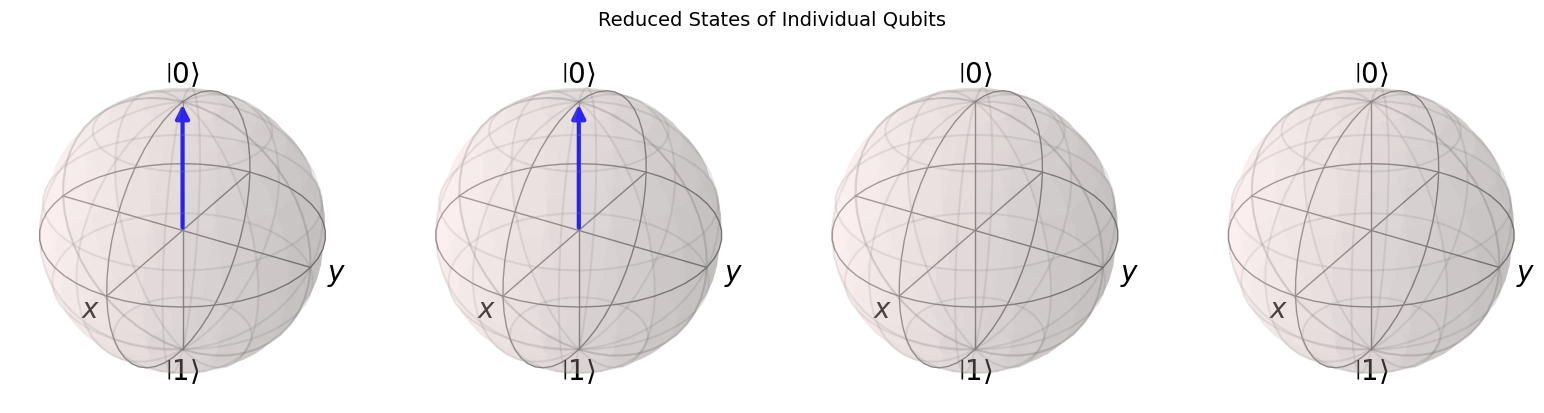

Observation:
- |00⟩: Both qubits are in pure state |0⟩ (north pole)
- |Φ⁺⟩: Each qubit is maximally mixed (center of Bloch sphere)
  → This is the signature of entanglement!


In [31]:
# ============================================================================
# VISUALIZING MULTI-QUBIT STATES (Projected)
# ============================================================================

print("=" * 70)
print("VISUALIZING MULTI-QUBIT STATES")
print("=" * 70)
print("\nNote: For 2-qubit states, we visualize the reduced density matrix")
print("of each qubit separately to understand their individual states.\n")

# Create figure for reduced states
fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw={'projection': '3d'})

# State 1: |00⟩
rho_00 = ket00 * ket00.dag()
rho_00_qubit0 = rho_00.ptrace(0)
rho_00_qubit1 = rho_00.ptrace(1)

bloch00_0 = qt.Bloch(fig=fig, axes=axes[0])
bloch00_0.add_states(rho_00_qubit0)
bloch00_0.vector_color = ['blue']
bloch00_0.title = "|00⟩: Qubit 0"
bloch00_0.render()

bloch00_1 = qt.Bloch(fig=fig, axes=axes[1])
bloch00_1.add_states(rho_00_qubit1)
bloch00_1.vector_color = ['blue']
bloch00_1.title = "|00⟩: Qubit 1"
bloch00_1.render()

# State 2: |Φ⁺⟩ (Bell state)
rho_phi = phi_plus * phi_plus.dag()
rho_phi_qubit0 = rho_phi.ptrace(0)
rho_phi_qubit1 = rho_phi.ptrace(1)

bloch_phi_0 = qt.Bloch(fig=fig, axes=axes[2])
bloch_phi_0.add_states(rho_phi_qubit0)
bloch_phi_0.vector_color = ['red']
bloch_phi_0.title = "|Φ⁺⟩: Qubit 0"
bloch_phi_0.render()

bloch_phi_1 = qt.Bloch(fig=fig, axes=axes[3])
bloch_phi_1.add_states(rho_phi_qubit1)
bloch_phi_1.vector_color = ['red']
bloch_phi_1.title = "|Φ⁺⟩: Qubit 1"
bloch_phi_1.render()

plt.suptitle("Reduced States of Individual Qubits", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Observation:")
print("- |00⟩: Both qubits are in pure state |0⟩ (north pole)")
print("- |Φ⁺⟩: Each qubit is maximally mixed (center of Bloch sphere)")
print("  → This is the signature of entanglement!")

VISUALIZING THE ENTANGLEMENT SPECTRUM


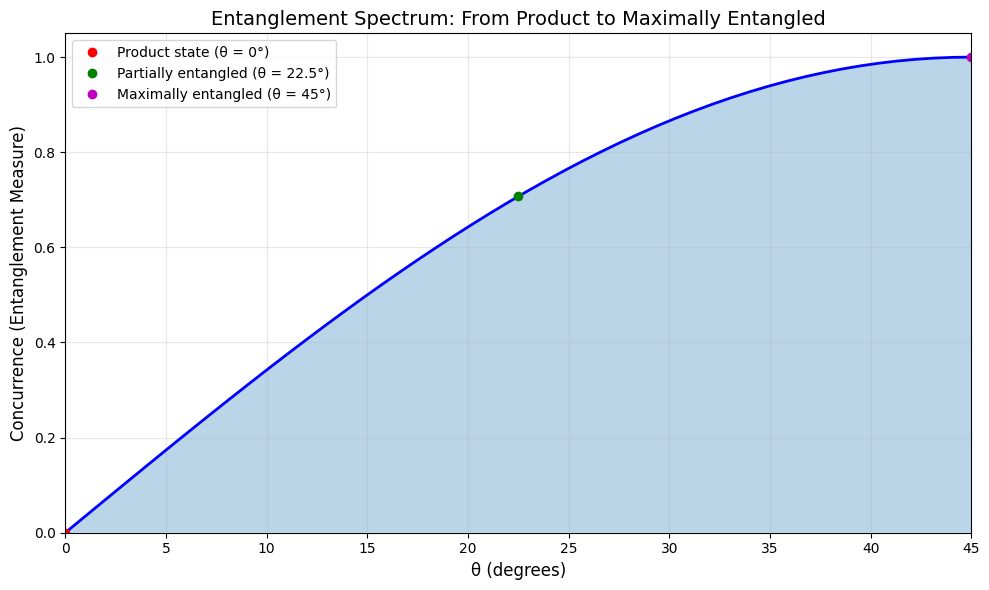


Observation: Concurrence increases from 0 to 1 as θ goes from 0° to 45°.
At θ = 0°: Product state (no entanglement)
At θ = 22.5°: Partially entangled
At θ = 45°: Maximally entangled


In [21]:
# ============================================================================
# VISUALIZING ENTANGLEMENT SPECTRUM
# ============================================================================

print("=" * 70)
print("VISUALIZING THE ENTANGLEMENT SPECTRUM")
print("=" * 70)

# Create a range of θ values
theta_range = np.linspace(0, np.pi/4, 50)
concurrence_values = 2 * np.sin(theta_range) * np.cos(theta_range)

# Plot concurrence vs θ
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(theta_range * 180/np.pi, concurrence_values, 'b-', linewidth=2)
ax.fill_between(theta_range * 180/np.pi, concurrence_values, alpha=0.3)

# Mark special points
ax.plot(0, 0, 'ro', label='Product state (θ = 0°)')
ax.plot(22.5, 2*np.sin(np.pi/8)*np.cos(np.pi/8), 'go', label='Partially entangled (θ = 22.5°)')
ax.plot(45, 1, 'mo', label='Maximally entangled (θ = 45°)')

ax.set_xlabel('θ (degrees)', fontsize=12)
ax.set_ylabel('Concurrence (Entanglement Measure)', fontsize=12)
ax.set_title('Entanglement Spectrum: From Product to Maximally Entangled', fontsize=14)
ax.set_xlim([0, 45])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("\nObservation: Concurrence increases from 0 to 1 as θ goes from 0° to 45°.")
print("At θ = 0°: Product state (no entanglement)")
print("At θ = 22.5°: Partially entangled")
print("At θ = 45°: Maximally entangled")

## 4c. Entanglement Distillation

### What is Entanglement Distillation?

The process of converting multiple copies of a **partially entangled** state into fewer copies of a **maximally entangled** state using only local operations and classical communication (LOCC).

### Why Distillation Matters

| Challenge | Solution |
|-----------|----------|
| Real quantum systems produce imperfect entanglement | Distillation purifies the entanglement |
| Noise and decoherence degrade entanglement | Recover maximally entangled states |
| Long-distance quantum communication requires high-quality entanglement | Essential for quantum repeaters |

### The Procrustean Method

Given multiple copies of a partially entangled state:

$$ |\psi\rangle = \cos\theta|00\rangle + \sin\theta|11\rangle $$

Apply local filtering operations to probabilistically concentrate entanglement.

### Entanglement Concentration (Schmidt Projection)

For two copies:

$$ |\psi\rangle^{\otimes 2} = (\cos\theta|00\rangle + \sin\theta|11\rangle)^{\otimes 2} $$

Project onto the subspace where both qubits are in the same state to obtain a maximally entangled state with some probability.

### Key Insight

Partial entanglement is a **resource** that can be upgraded to maximal entanglement through distillation protocols. This is crucial for quantum repeaters and long-distance quantum communication.

In [22]:
# ============================================================================
# ENTANGLEMENT DISTILLATION DEMONSTRATION (Conceptual)
# ============================================================================

print("=" * 70)
print("ENTANGLEMENT DISTILLATION CONCEPT")
print("=" * 70)

# Start with a partially entangled state
theta = np.pi/8  # 22.5°
cos_t = np.cos(theta)
sin_t = np.sin(theta)

print(f"\nStarting with partially entangled state:")
print(f"|ψ⟩ = {cos_t:.4f}|00⟩ + {sin_t:.4f}|11⟩")
print(f"Concurrence = {2*abs(cos_t*sin_t):.4f}")

# After distillation (conceptually)
print(f"\nAfter distillation (multiple copies + LOCC):")
print(f"|Φ⁺⟩ = (|00⟩ + |11⟩)/√2")
print(f"Concurrence = 1.000 (maximally entangled)")

print("\n" + "=" * 70)
print("ENTANGLEMENT DISTILLATION PROTOCOL (BBPSSW)")
print("=" * 70)

print("""
The BBPSSW protocol (Bennett, Brassard, Popescu, Schumacher, Smolin, Wootters):

1. Start with two copies of a partially entangled state
2. Apply CNOT gates between copies
3. Measure certain qubits
4. Post-select on measurement outcomes
5. Result: Maximally entangled state (with some probability)

Applications:
- Quantum repeaters for long-distance communication
- Purification of noisy entanglement
- Fault-tolerant quantum computing
""")

print("=" * 70)

ENTANGLEMENT DISTILLATION CONCEPT

Starting with partially entangled state:
|ψ⟩ = 0.9239|00⟩ + 0.3827|11⟩
Concurrence = 0.7071

After distillation (multiple copies + LOCC):
|Φ⁺⟩ = (|00⟩ + |11⟩)/√2
Concurrence = 1.000 (maximally entangled)

ENTANGLEMENT DISTILLATION PROTOCOL (BBPSSW)

The BBPSSW protocol (Bennett, Brassard, Popescu, Schumacher, Smolin, Wootters):

1. Start with two copies of a partially entangled state
2. Apply CNOT gates between copies
3. Measure certain qubits
4. Post-select on measurement outcomes
5. Result: Maximally entangled state (with some probability)

Applications:
- Quantum repeaters for long-distance communication
- Purification of noisy entanglement
- Fault-tolerant quantum computing



## 4d. Entanglement Measures Summary

### Comparing Entanglement Measures

| Measure | Formula | Best For | Range |
|---------|---------|----------|-------|
| **Concurrence** | $C = 2|\alpha\beta|$ | 2-qubit pure states | 0 to 1 |
| **Entanglement of Formation** | $E_f = h\left(\frac{1+\sqrt{1-C^2}}{2}\right)$ | Mixed states | 0 to 1 |
| **Schmidt Number** | Number of Schmidt coefficients | Detecting entanglement | 1 to d |
| **Negativity** | $N = \frac{\|\rho^{T_B}\|_1 - 1}{2}$ | Mixed states (any dimension) | 0 to 0.5 |
| **Logarithmic Negativity** | $E_N = \log_2 \|\rho^{T_B}\|_1$ | Mixed states (any dimension) | 0 to ∞ |

### Key Insights

1. **Maximally entangled states** have the strongest possible quantum correlations
2. **Partially entangled states** are more common in real quantum systems
3. **Entanglement is a resource** that can be quantified and manipulated
4. **Distillation protocols** convert partial entanglement into maximal entanglement
5. **Different measures** are useful for different scenarios

### Takeaway

Not all entanglement is equal. Understanding the spectrum from product to maximally entangled states is crucial for practical quantum information processing.


VISUALIZING PARTIAL ENTANGLEMENT


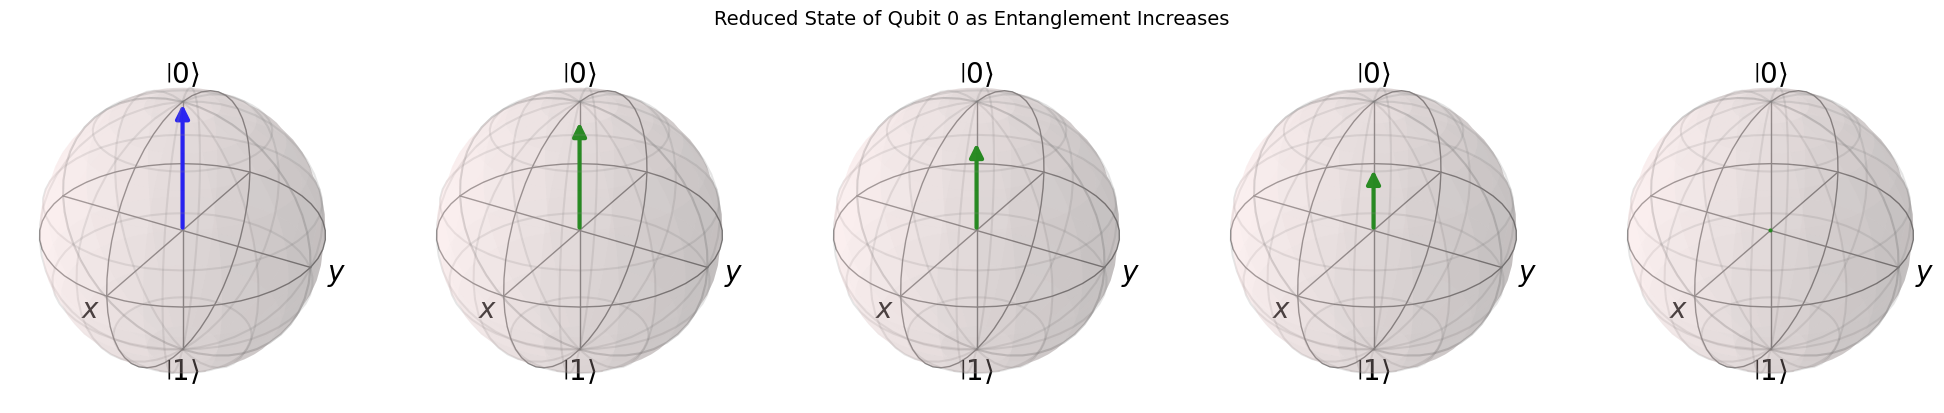


Observations:
- θ = 0° (Product): Qubit 0 is pure |0⟩ (blue vector at north pole)
- θ = 15° to 30° (Partial): Qubit 0 becomes partially mixed (moves toward center)
- θ = 45° (Maximal): Qubit 0 is maximally mixed (at center, no vector)

✅ As entanglement increases, local information decreases!


In [33]:
# ============================================================================
# VISUALIZING PARTIAL ENTANGLEMENT ON BLOCH SPHERE
# ============================================================================

print("\n" + "=" * 70)
print("VISUALIZING PARTIAL ENTANGLEMENT")
print("=" * 70)

# Create states with different entanglement levels
theta_values = [0, np.pi/12, np.pi/8, np.pi/6, np.pi/4]
theta_labels = ["Product (θ=0°)", "Partial (θ=15°)", "Partial (θ=22.5°)", "Partial (θ=30°)", "Maximal (θ=45°)"]
colors = ['blue', 'cyan', 'green', 'orange', 'red']

fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw={'projection': '3d'})

for idx, (theta, label, color) in enumerate(zip(theta_values, theta_labels, colors)):
    # Create state |ψ⟩ = cosθ|00⟩ + sinθ|11⟩
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    psi = cos_t * ket00 + sin_t * ket11
    psi = psi.unit()

    # Get reduced density matrix for first qubit
    rho = psi * psi.dag()
    rho_q0 = rho.ptrace(0)

    # Calculate purity (1 = pure, 0.5 = maximally mixed)
    purity = (rho_q0 * rho_q0).tr().real

    # Plot on Bloch sphere
    bloch = qt.Bloch(fig=fig, axes=axes[idx])

    # For pure state, show vector; for mixed, show sphere point
    if purity > 0.99:
        # Pure state - show vector
        bloch.add_states(rho_q0)
        bloch.vector_color = [color]
    else:
        # Mixed state - show point at center
        bloch.add_states(rho_q0)
        bloch.point_color = [color]
        bloch.point_marker = ['o']

    bloch.title = f"{label}\nPurity = {purity:.3f}"
    bloch.render()

plt.suptitle("Reduced State of Qubit 0 as Entanglement Increases", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- θ = 0° (Product): Qubit 0 is pure |0⟩ (blue vector at north pole)")
print("- θ = 15° to 30° (Partial): Qubit 0 becomes partially mixed (moves toward center)")
print("- θ = 45° (Maximal): Qubit 0 is maximally mixed (at center, no vector)")
print("\n✅ As entanglement increases, local information decreases!")

## 5. Other Important Multi-Qubit Gates

### SWAP Gate

Swaps the states of two qubits:

$$ \text{SWAP} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix} $$

### CZ Gate (Controlled-Z)

Applies Z gate to target if control is |1⟩:

$$ \text{CZ} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1
\end{pmatrix} $$

### Toffoli Gate (CCNOT)

Controlled-Controlled-NOT: 3-qubit gate that flips target only if both controls are |1⟩. Universal for classical reversible computing.

### Fredkin Gate (CSWAP)

Controlled-SWAP: Swaps two qubits if control is |1⟩.

### Gate Summary

| Gate | Symbol | Effect | Entangling? |
|------|--------|--------|-------------|
| CNOT | ●─⊕─ | Flips target if control=1 | Yes |
| SWAP | ×─× | Swaps two qubits | No |
| CZ | ●─●─ | Applies Z if control=1 | Yes |
| Toffoli | ●─●─⊕─ | Flips if both controls=1 | Yes |

In [30]:
# ============================================================================
# OTHER MULTI-QUBIT GATES (PURE QUTIP — CORRECT)
# ============================================================================

import numpy as np
import qutip as qt

print("=" * 70)
print("OTHER MULTI-QUBIT GATES")
print("=" * 70)

# ----------------------------------------------------------------------------
# Basis states
# ----------------------------------------------------------------------------
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

ket00 = qt.tensor(ket0, ket0)
ket01 = qt.tensor(ket0, ket1)
ket10 = qt.tensor(ket1, ket0)
ket11 = qt.tensor(ket1, ket1)

# ----------------------------------------------------------------------------
# SWAP GATE (manual definition)
# ----------------------------------------------------------------------------
SWAP = qt.Qobj([
    [1,0,0,0],
    [0,0,1,0],
    [0,1,0,0],
    [0,0,0,1]
], dims=[[2,2],[2,2]])

print("\nSWAP Gate Matrix:")
print(SWAP)

# Test SWAP
print(f"\nSWAP|01⟩ = {SWAP * ket01}")
print(f"Expected: |10⟩ = {ket10}")

# ----------------------------------------------------------------------------
# CZ GATE (Controlled-Z)
# ----------------------------------------------------------------------------
CZ = qt.Qobj([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,1,0],
    [0,0,0,-1]
], dims=[[2,2],[2,2]])

print("\nCZ Gate Matrix:")
print(CZ)

# Test CZ
print(f"\nCZ|11⟩ = {CZ * ket11}")
print(f"Expected: -|11⟩ = {-ket11}")

print(f"CZ|00⟩ = {CZ * ket00}")
print(f"CZ|01⟩ = {CZ * ket01}")
print(f"CZ|10⟩ = {CZ * ket10}")

# ----------------------------------------------------------------------------
# TOFFOLI GATE (CCNOT)
# ----------------------------------------------------------------------------
# ----------------------------------------------------------------------------
# TOFFOLI GATE (CORRECT CONSTRUCTION)
# ----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("TOFFOLI GATE (CCNOT)")
print("=" * 70)

# 3-qubit basis
ket000 = qt.tensor(ket0, ket0, ket0)
ket110 = qt.tensor(ket1, ket1, ket0)
ket111 = qt.tensor(ket1, ket1, ket1)

# Start with identity matrix
toffoli_matrix = np.eye(8)

# Modify entries (swap |110⟩ and |111⟩)
toffoli_matrix[6,6] = 0
toffoli_matrix[7,7] = 0
toffoli_matrix[6,7] = 1
toffoli_matrix[7,6] = 1

# Convert to Qobj
TOFFOLI = qt.Qobj(toffoli_matrix, dims=[[2,2,2],[2,2,2]])

print("\nToffoli Gate Matrix:")
print(TOFFOLI)

# Test Toffoli
print(f"\nToffoli|110⟩ = {TOFFOLI * ket110}")
print(f"Expected: |111⟩ = {ket111}")

print(f"Toffoli|000⟩ = {TOFFOLI * ket000} (unchanged)")

OTHER MULTI-QUBIT GATES

SWAP Gate Matrix:
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]

SWAP|01⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [1.]
 [0.]]
Expected: |10⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [1.]
 [0.]]

CZ Gate Matrix:
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0. -1.]]

CZ|11⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.]
 [ 0.]
 [ 0.]
 [-1.]]
Expected: -|11⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[-0.]
 [-0.]
 [-0.]
 [-1.]]
CZ|00⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj

## 6. Summary and Key Insights

### Key Concepts

| Concept | Description |
|---------|-------------|
| Tensor Product | Combines Hilbert spaces of multiple qubits |
| Separable State | Can be written as product of individual states |
| Entangled State | Cannot be written as product state |
| Bell States | Maximally entangled 2-qubit basis |
| CNOT Gate | Controlled-NOT, fundamental entangling gate |
| Universal Gate Set | {H, S, T, CNOT} can approximate any quantum circuit |

### Bell States Summary

| Bell State | Formula | Circuit |
|------------|---------|---------|
| $|\Phi^+\rangle$ | $\frac{|00\rangle + |11\rangle}{\sqrt{2}}$ | $H_1$ then CNOT |
| $|\Phi^-\rangle$ | $\frac{|00\rangle - |11\rangle}{\sqrt{2}}$ | $H_1$ then CNOT then $Z_1$ |
| $|\Psi^+\rangle$ | $\frac{|01\rangle + |10\rangle}{\sqrt{2}}$ | $X_2$ then $H_1$ then CNOT |
| $|\Psi^-\rangle$ | $\frac{|01\rangle - |10\rangle}{\sqrt{2}}$ | $X_2$ then $H_1$ then CNOT then $Z_1$ |

### Key Takeaways

1. **Multi-qubit states** are represented using tensor products
2. **Entanglement** is a uniquely quantum correlation with no classical analog
3. **CNOT** is the fundamental entangling gate that enables quantum advantage
4. **Bell states** are maximally entangled and form a basis for 2-qubit systems
5. **Universal quantum computation** requires both single-qubit gates and at least one entangling gate (like CNOT)

### The Road Ahead

Next topics will cover:
- Quantum circuits and algorithms
- Deutsch-Jozsa algorithm
- Grover's search algorithm
- Quantum Fourier transform

---

**Day 3 Complete!** 🎉

You now understand:
- How to represent and manipulate multi-qubit states
- The CNOT gate and how it creates entanglement
- All four Bell states and how to generate them
- The properties that make entanglement unique
- Other important multi-qubit gates (SWAP, CZ, Toffoli)

Proceed to Day 4 when ready.